[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Dragomier/Machine_Learning_2026/blob/main/Homework7.ipynb)

# Exercise 1
We will try to find analytically the optimal parameter $\lambda$ in two scenarios:

- Scenario A -- $\lambda$ is a single-parameter predictor built from scratch.
- Scenario B -- $\lambda$ is an additive shift, chosen during forward stagewise procedure.

**Scenario A**

Let $f(\lambda) = \sum\limits_{i = 1}^{m + k} (-y_i \log(\frac{1}{1 + e^{-\lambda}}) -(1 - y_i)\log(1 - \frac{1}{1 + e^{-\lambda}})))$. To obtain $\lambda^*$, which minimizes this expression, we calculate the derivative of *f* with respect to $\lambda$ and set it to zero.

$$ f'(\lambda)  = \sum\limits_{i = 1}^{m + k} (-y_i (1 + e^{-\lambda})(\frac{1}{1 + e^{-\lambda}})^2 + (1-y_i)(\frac{1 + e^{-\lambda}}{e^{-\lambda}})(\frac{1}{1 + e^{-\lambda}})^2)$$

$$ f'(\lambda)  = \sum\limits_{i = 1}^{m + k} (-\frac{y_i}{1 + e^{-\lambda}} + \frac{1-y_i}{e^{-\lambda}(1 + e^{-\lambda})})$$

Expressions in the denominators does not depend on $i$, so we sum only over $y$'s. From the problem we know, that $\sum\limits_{i = 1}^{m + k} y_i = m$, so we use this fact and obtain:

$$ f'(\lambda)  = \sum\limits_{i = 1}^{m + k} -\frac{y_i}{1 + e^{-\lambda}} + \sum\limits_{i = 1}^{m + k}\frac{1}{e^{-\lambda}(1 + e^{-\lambda})}  - \sum\limits_{i = 1}^{m + k} \frac{y_i}{e^{-\lambda}(1 + e^{-\lambda})} $$

$$ f'(\lambda)  = -\frac{m}{1 + e^{-\lambda}} + \frac{m + k}{e^{-\lambda}(1 + e^{-\lambda})} - \frac{m}{e^{-\lambda}(1 + e^{-\lambda})} $$

To calculate minimum of $f(\lambda)$ we set the derivative to 0:

$$-\frac{m}{1 + e^{-\lambda}} + \frac{m + k}{e^{-\lambda}(1 + e^{-\lambda})} - \frac{m}{e^{-\lambda}(1 + e^{-\lambda})} = 0$$

$$-me^{-\lambda} +m + k - m = 0$$

$$e^{-\lambda} = \frac{k}{m}$$

$$\lambda = \log(\frac{m}{k})$$

We observe that $-f(\lambda)$ is convex combination of concave functions, so it is also concave. From then we conclude that $f(\lambda)$ is convex function, so its derivative $f'(\lambda)$ is strictly positive and the only extremum of $f(\lambda)$ is global minimum, so

 $$\operatorname{argmin}_{\lambda} f(\lambda) =\log(\frac{m}{k}).$$

This constant represents logarithm of the ratio between number of ones and the number of zeros in the labels $y_i$.

**Scenario B**

We try to do the same as in *Scenario A*.

Let $f(\lambda) = \sum\limits_{i = 1}^{m + k} (-y_i \log(\frac{1}{1 + e^{-(\lambda + f_i)}}) -(1 - y_i)\log(1 - \frac{1}{1 + e^{-(\lambda + f_i)}})))$. To obtain $\lambda^*$, which minimizes this expression, we calculate the derivative of *f* with respect to $\lambda$ and set it to zero.

$$ f'(\lambda)  = \sum\limits_{i = 1}^{m + k} (-y_i (1 + e^{-(\lambda + f_i)})(\frac{1}{1 + e^{-(\lambda + f_i)}})^2 + (1-y_i)(\frac{1 + e^{-(\lambda + f_i)}}{e^{-(\lambda + f_i)}})(\frac{1}{1 + e^{-(\lambda + f_i)}})^2)$$

$$ f'(\lambda)  = \sum\limits_{i = 1}^{m + k} (-\frac{y_i}{1 + e^{-(\lambda + f_i)}} + \frac{1-y_i}{e^{-(\lambda + f_i)}(1 + e^{-(\lambda + f_i)})})$$

To calculate minimum of $f(\lambda)$ we set the derivative to 0:

$$\sum\limits_{i = 1}^{m + k} (-\frac{y_i}{1 + e^{-(\lambda + f_i)}} + \frac{1-y_i}{e^{-(\lambda + f_i)}(1 + e^{-(\lambda + f_i)})}) = 0$$

Now, the value in the denominator is not constant, so if we tried to find a common denominator for this expression would get something very complicated, which has no simple form, as in the previous scenario. If the sigmoid function was linear, we could split the function into part with lambda and part with known $f_i$'s, which in our case are constants, so calculations would be easy.

$$\sigma(\lambda + f_i) \neq \sigma(\lambda) + \sigma(f_i)$$

# Exercise 2
In the next two cells we plot two graphs of functions. The first one ilustrates how the binary-crossed loss depends on a parameter lambda when it is a single-parameter chosen from scratch. The second one ilustrates how the binary-crossed loss depends on a parameter lambda, when it is an additive shift chosen during the forward stagewise procedure.

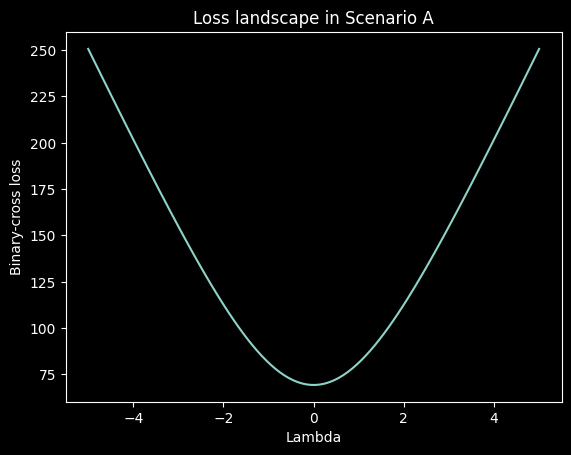

In [56]:
import numpy as np
import matplotlib.pyplot as plt

m = 50
k = 50
n = m + k

labels = np.array(m * [1] + k * [0], dtype = float)
np.random.shuffle(labels)

def binary_cross_entropy(args, labels):
    result = []
    for arg in args:
        p = 1 / (1 + np.exp(-arg))
        loss = -1 * np.sum(labels * np.log(p) + (1 - labels) * np.log(1 - p))
        result.append(loss)
    return result

x = np.linspace(-5, 5, 100)
y = binary_cross_entropy(x, labels)
plt.xlabel("Lambda")
plt.ylabel("Binary-cross loss")
plt.title("Loss landscape in Scenario A")

plt.plot(x, y)


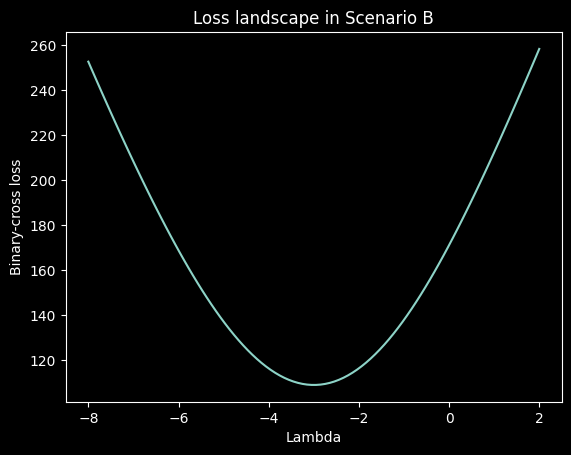

In [66]:
predictions = np.random.normal(loc = 3, scale = 2, size = n)
def binary_cross_predictions(predictions, lambdas, labels):
    result = []
    for arg in lambdas:
        p = 1 / (1 + np.exp(-arg - predictions))
        result.append(np.sum(-1*labels * np.log(p) - (1 - labels) * np.log(1 - p)))
    return result
x = np.linspace(-8, 2, 100)
y = binary_cross_predictions(predictions, x, labels)
plt.xlabel("Lambda")
plt.ylabel("Binary-cross loss")
plt.title("Loss landscape in Scenario B")

plt.plot(x, y)

# Conclusion
In both scenarios we can see unimodal loss landscapes. Both graphs are stricly convex. Even if we couldn't calculate analytically the optimal $\lambda$ in *Scenario B*, as we did succesfully in *Scenario A*, we could still approximate it using numerical algorithms like Gradient Descent. We found out that the difficulty in *Scenario B* came from non-linearity of a problem.